In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [6]:
ghcn = pd.read_csv('/Datastorage/saptarishi.dhanuka_asp25/noaa_data_20100101_20250531.csv')
print(ghcn)

         Unnamed: 0           ID        DATE  DATA_VALUE M_FLAG Q_FLAG S_FLAG  \
0                 0  AFM00040948  2018-07-05        31.7    NaN    NaN      S   
1                 1  AFM00040948  2018-07-06        33.1    NaN    NaN      S   
2                 2  AFM00040948  2018-07-07        36.3    NaN    NaN      S   
3                 3  AFM00040948  2018-07-09        38.6    NaN    NaN      S   
4                 4  AFM00040948  2018-07-10        38.4    NaN    NaN      S   
...             ...          ...         ...         ...    ...    ...    ...   
1610502     1610502  PKM00041780  2025-05-27         0.0      B    NaN      S   
1610503     1610503  PKM00041780  2025-05-28         0.0    NaN    NaN      S   
1610504     1610504  PKM00041780  2025-05-29         0.0    NaN    NaN      S   
1610505     1610505  PKM00041780  2025-05-30         0.0    NaN    NaN      S   
1610506     1610506  PKM00041780  2025-05-31         0.0    NaN    NaN      S   

         OBS_TIME ELEMENT  

/tmp/ipykernel_98863/4237579020.py:1: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  ghcn = pd.read_csv('/Datastorage/saptarishi.dhanuka_asp25/noaa_data_20100101_20250531.csv')


In [5]:
ghcn_meta =  pd.read_csv('/Datastorage/saptarishi.dhanuka_asp25/noaa_ghcn_meta.csv')
print(ghcn_meta)

     Unnamed: 0           ID  LATITUDE  LONGITUDE ELEMENT  FIRSTYEAR  \
0            44  AFM00040948    34.566     69.212    TMAX       1966   
1            45  AFM00040948    34.566     69.212    TMIN       1967   
2            46  AFM00040948    34.566     69.212    PRCP       1983   
3            47  AFM00040948    34.566     69.212    SNWD       1974   
4            49  AFM00040990    31.500     65.850    TMAX       1973   
..          ...          ...       ...        ...     ...        ...   
649      163250  PKM00041768    25.517     69.783    TMIN       1957   
650      163251  PKM00041768    25.517     69.783    PRCP       1957   
651      163253  PKM00041780    24.907     67.161    TMAX       1942   
652      163254  PKM00041780    24.907     67.161    TMIN       1942   
653      163255  PKM00041780    24.907     67.161    PRCP       1942   

     LASTYEAR               geometry  start_date    end_date  
0        2021  POINT (69.212 34.566)  2010-01-01  2021-12-31  
1        

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_rivers_lake

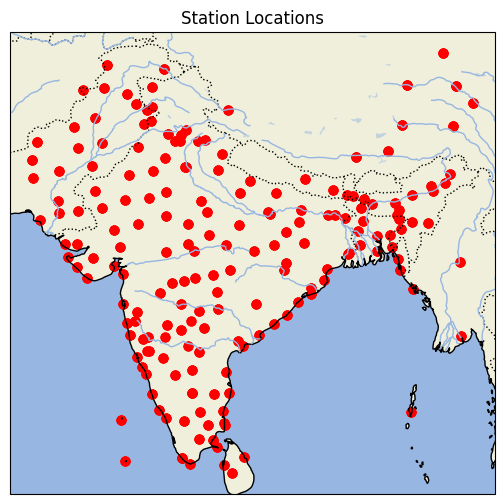

In [6]:
df = ghcn_meta
# Plot
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_title('Station Locations')

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

# Scatter plot
ax.scatter(df['LONGITUDE'], df['LATITUDE'], color='red', s=40, marker='o', transform=ccrs.PlateCarree())

# Zoom to the region
# ax.set_extent([ 70, 35, 45], crs=ccrs.PlateCarree())  # adjust bounds as needed
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import io


In [8]:
value_df = ghcn
metadata_df = ghcn_meta

In [9]:
prcp_values = value_df[value_df['ELEMENT'] == 'PRCP'].copy()
prcp_metadata = metadata_df[metadata_df['ELEMENT'] == 'PRCP'].copy()

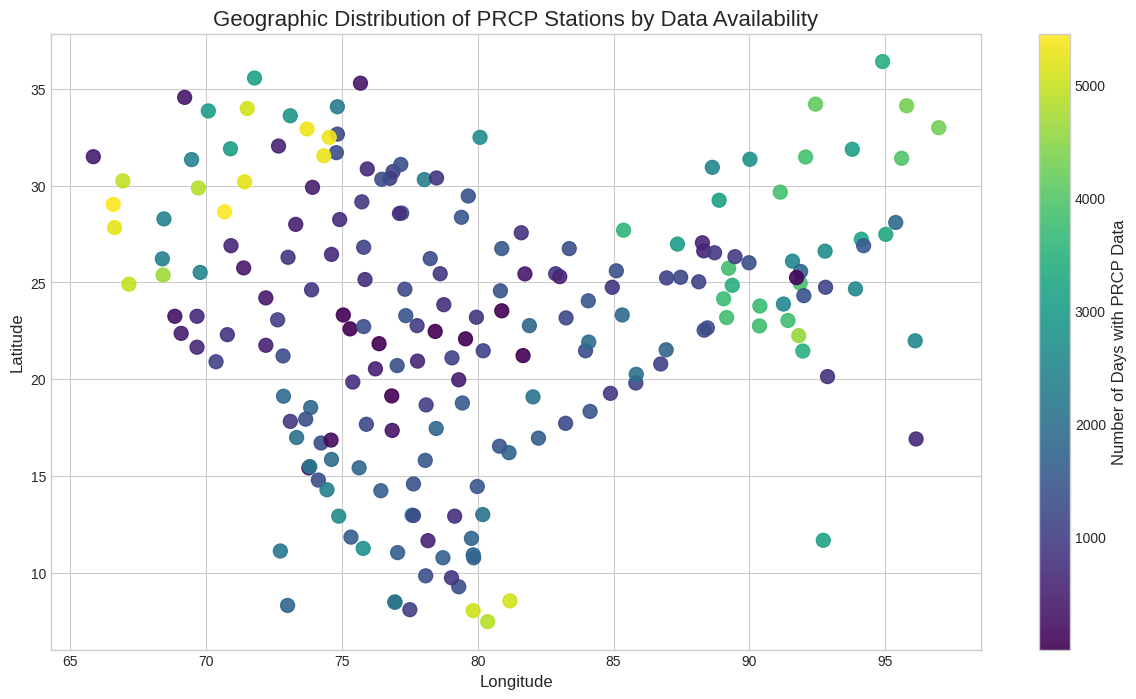

In [10]:
# --- 3. Count Data Days ---
# Group by the station ID and count the number of observations (days) for each.
# We reset the index to turn the grouped output back into a DataFrame.
days_of_data = prcp_values.groupby('ID')['DATE'].count().reset_index(name='days_of_data')

# --- 4. Merge Datasets ---
# Get unique station locations from the metadata to avoid duplicates.
prcp_metadata_unique = prcp_metadata.drop_duplicates(subset='ID', keep='first')

# Merge the day counts with the station metadata on the 'ID' column.
# An 'inner' join ensures we only plot stations present in both datasets.
plot_data = pd.merge(days_of_data, prcp_metadata_unique, on='ID', how='inner')

# --- 5. Plot the Map ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 8))

# Create the scatter plot
# x-axis: LONGITUDE
# y-axis: LATITUDE
# c (color): Mapped to the number of data days for each station
# cmap: The colormap to use (e.g., 'viridis', 'plasma', 'coolwarm')
scatter = plt.scatter(
    x=plot_data['LONGITUDE'],
    y=plot_data['LATITUDE'],
    c=plot_data['days_of_data'],
    cmap='viridis',
    alpha=0.9,
    s=100  # Size of the points
)

# Add a title and labels for clarity
plt.title('Geographic Distribution of PRCP Stations by Data Availability', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Add a color bar to show what the colors represent
cbar = plt.colorbar(scatter)
cbar.set_label('Number of Days with PRCP Data', fontsize=12)

# Display the plot
plt.show()

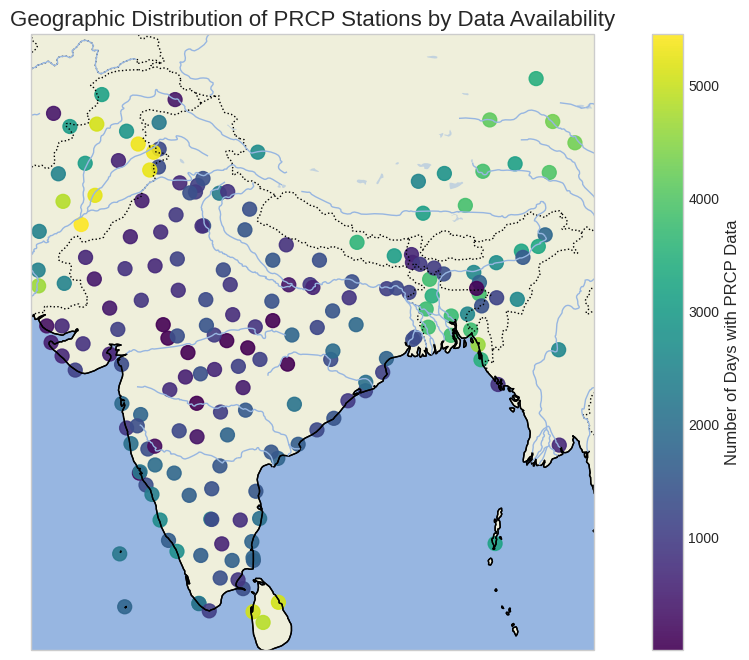

In [12]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import pandas as pd

# Your previous code remains the same until plotting

# ---5. Plot the Map ---
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add some map features
ax.coastlines()
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

# Create the scatter plot
# x-axis: LONGITUDE
# y-axis: LATITUDE
# c (color): Mapped to the number of data days for each station
# cmap: The colormap to use (e.g., 'viridis', 'plasma', 'coolwarm')
scatter = ax.scatter(
    plot_data['LONGITUDE'],
    plot_data['LATITUDE'],
    c=plot_data['days_of_data'],
    cmap='viridis',
    alpha=0.9,
    s=100, # Size of the points
    transform=ccrs.PlateCarree() # Specify the projection
)

# Add a title and labels for clarity
ax.set_title('Geographic Distribution of PRCP Stations by Data Availability', fontsize=16)

# Add a color bar to show what the colors represent
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Number of Days with PRCP Data', fontsize=12)

# Set the extent to focus on India
# You can adjust these values as needed
ax.set_extent([68, 98, 6, 38]) # roughly the bounds of India

# Display the plot
plt.show()